In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import re
import math

# Get voter data and vote share for enacted and 2021 Proposal 1

In [2]:
votes_df=pd.read_csv('./data/voter_numbers_2022.csv')
# votes_df['indep_votes'] = votes_df['indep_votes'].replace(np.nan, 0).astype(int)
votes_df['total_votes'] =  votes_df[['dem_votes', 'rep_votes']].sum(axis=1)
votes_df

,county_id,NAME10,dem_votes,rep_votes,indep_votes,og_district,alt_district,total_votes
0,0,Adair,973,2166,NaN,3,4,3139
1,1,Adams,510,1126,NaN,3,3,1636
2,2,Allamakee,1932,3820,NaN,2,2,5752
3,3,Appanoose,1412,3249,NaN,3,3,4661
4,4,Audubon,633,1639,51.0,4,4,2272
...,...,...,...,...,...,...,...,...
94,94,Winnebago,1303,2924,101.0,4,4,4227
95,95,Winneshiek,4445,5135,NaN,2,2,9580
96,96,Woodbury,9601,18234,533.0,4,4,27835
97,97,Worth,1189,2031,NaN,2,4,3220


In [4]:
enacted_rep_vote_share_list=[]
for i in range(1,5):
    total_votes=votes_df.loc[votes_df['og_district']==i]['total_votes'].sum()
    total_rep_votes=votes_df.loc[votes_df['og_district']==i]['rep_votes'].sum()
    rep_vote_share=total_rep_votes/total_votes
    enacted_rep_vote_share_list.append(rep_vote_share)

In [5]:
alternate_rep_vote_share_list=[]
for i in range(1,5):
    total_votes=votes_df.loc[votes_df['alt_district']==i]['total_votes'].sum()
    total_rep_votes=votes_df.loc[votes_df['alt_district']==i]['rep_votes'].sum()
    rep_vote_share=total_rep_votes/total_votes
    alternate_rep_vote_share_list.append(rep_vote_share)

# Functions

## Seat Share

In [6]:
def winner_tabulation(votes_df, realloc_df):
    votes_df['simulation_district']=realloc_df['DISTRICT']
    winners_df=pd.DataFrame(columns=['district', 'dem_votes', 'rep_votes', 'party_winner'])
    for i in range(1,5):
        winners_df.loc[i]=[i,
                      votes_df.loc[votes_df['simulation_district']==i]['dem_votes'].sum(),
                      votes_df.loc[votes_df['simulation_district']==i]['rep_votes'].sum(),
                    # votes_df.loc[votes_df['simulation_district']==i]['indep_votes'].sum(),
                      '']
    for i in range(1,5):
        if votes_df.loc[votes_df['simulation_district']==i]['dem_votes'].sum()>votes_df.loc[votes_df['simulation_district']==i]['rep_votes'].sum():
            winners_df.loc[winners_df['district']==i,'party_winner']='D'
        else:
            winners_df.loc[winners_df['district']==i,'party_winner']='R'
    return winners_df

## Vote share

In [7]:
#returns Republican percentage vote share in each district as a list in ascending order
def rep_vote_share_as_list(votes_df, realloc_df):
    votes_df['simulation_district']=realloc_df['DISTRICT']
    rep_vote_share_list=[]
    for i in range(1,5):
        total_votes=votes_df.loc[votes_df['simulation_district']==i]['total_votes'].sum()
        total_rep_votes=votes_df.loc[votes_df['simulation_district']==i]['rep_votes'].sum()
        rep_vote_share=total_rep_votes/total_votes
        rep_vote_share_list.append(rep_vote_share)
    return sorted(rep_vote_share_list)

## Efficiency Gap

In [8]:
# first argument is the voter number dataframe, second argument is the simulation dataframe with new district assignments
# output is total democrat and republican votes in each district, along with the winning number based on votes cast in district
def district_totals(votes_df, realloc_df):
    votes_df['simulation_district']=realloc_df['DISTRICT']
    district_votes=pd.DataFrame(columns=['district', 'dem_votes', 'rep_votes', 'votes_to_win'])
    for i in range(1,5):
        district_total= votes_df.loc[votes_df['simulation_district']==i]['total_votes'].sum()
        votes_to_win = 0
        if district_total % 2 ==0:
            votes_to_win = votes_to_win+(district_total/2) + 1
        else:
            votes_to_win = votes_to_win+math.ceil(district_total/2)
        district_votes.loc[i]=[i,
                      votes_df.loc[votes_df['simulation_district']==i]['dem_votes'].sum()
                      , votes_df.loc[votes_df['simulation_district']==i]['rep_votes'].sum()
                      , votes_to_win]
    return district_votes 

# input is datadrame with votes by party breakdown in each district with votes needed to win the district
# output is the wasted votes for democrats and republicans

def wasted_votes(district_votes):
    dem_wasted=0
    rep_wasted=0
    for i in range(4):
        if district_votes.iloc[i]['dem_votes']>district_votes.iloc[i]['rep_votes']:
            dem_wasted+= district_votes.iloc[i]['dem_votes']-district_votes.iloc[i]['votes_to_win']
            rep_wasted+=district_votes.iloc[i]['rep_votes']
        else:
            dem_wasted+= district_votes.iloc[i]['dem_votes']
            rep_wasted+=district_votes.iloc[i]['rep_votes']-district_votes.iloc[i]['votes_to_win']
    return dem_wasted, rep_wasted

In [ ]:
# compute EG for a given district map. Inputs are the union of district_totals and wasted_votes functions
# output is the efficiency gap as a percentage, rounded to 1 decimal place
def EG_func(votes_df, realloc_df):
    district_votes=district_totals(votes_df, realloc_df)
    total_votes = votes_df['total_votes'].sum()
    all_wasted_votes=wasted_votes(district_votes)
    efficiency_gap = round(((all_wasted_votes[0]-all_wasted_votes[1])/total_votes)*100,2)
    return efficiency_gap

## Mean-Median Difference

In [20]:
# compute Republican mean median difference for district map
# Arguments are election dataframe and dataframe with district assignments
# Output is the mean-median difference as a percent, rounded to two decimal places
def mean_med_diff(votes_df, realloc_df):
    rep_vote_share = rep_vote_share_as_list(votes_df, realloc_df)
    median = (rep_vote_share[1]+rep_vote_share[2])/2
    mean = sum(rep_vote_share)/len(rep_vote_share)
    mean_med_diff = round((mean - median)*100, 2)
    return mean_med_diff

# Analysis 

## Percent vote share

In [36]:
# Create dataframe with Republican percent vote share in each district
# Column headers 1-4 refer to ascending order of vote share, not district number
files = glob.glob('./allocation_by_county/*.csv')
file_name = './allocation_by_county/seed_{}_by_county.csv'
rep_percent_vote_share_df=pd.DataFrame(columns=['1', '2', '3', '4'])
for i in range(len(files)):
    iter_number=str(i).rjust(3,'0')
    realloc_df=pd.read_csv(file_name.format(iter_number))
    votes_df['simulation_district']=realloc_df['DISTRICT']
    rep_percent_vote_share_df.loc[len(rep_percent_vote_share_df)]=rep_vote_share_as_list(votes_df, realloc_df)

In [37]:
#unstack dataframe to prep for graphics
simulation_df=rep_percent_vote_share_df.unstack().reset_index(drop=False)
simulation_df=simulation_df.drop(columns=['level_1'])
simulation_df=simulation_df.rename(columns={"level_0": "rank_order", 0:"percentage"})
simulation_df

,rank_order,percentage
0,1,0.501760
1,1,0.515436
2,1,0.493602
3,1,0.476467
4,1,0.499617
...,...,...
1035,4,0.703425
1036,4,0.680686
1037,4,0.679629
1038,4,0.653391


In [13]:
# Create vote share for enacted (Proposal 2) and alternate (Proposal 1) 2021 maps for scatterplot and boxplot overlay
list=sorted(enacted_rep_vote_share_list)
enacted_dict={'rank_order':[0,1,2,3], 'percentage': list}
enacted_map_df=pd.DataFrame(enacted_dict)

list2=sorted(alternate_rep_vote_share_list)
alternate_dict = {'rank_order':[0,1,2,3], 'percentage': list2}
alternate_map_df=pd.DataFrame(alternate_dict)

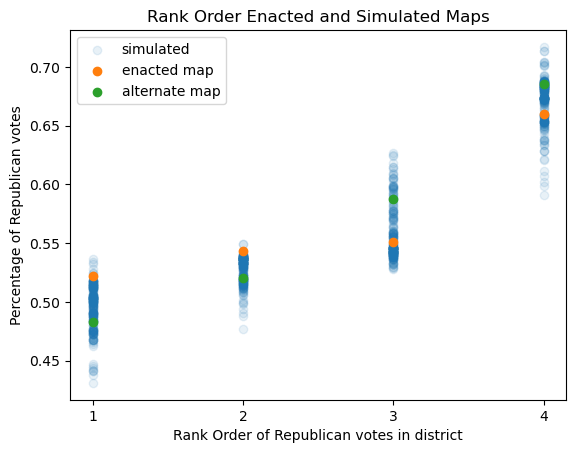

In [39]:
X=simulation_df['rank_order']
Y=simulation_df['percentage']
x=enacted_map_df['rank_order']
y=enacted_map_df['percentage']
a=alternate_map_df['rank_order']
b=alternate_map_df['percentage']

plt.scatter(X, Y, alpha=.1, zorder=1, label='simulated')
plt.scatter(x, y, zorder=2, label='enacted map')
plt.scatter(a, b, zorder=3, label='alternate map')
plt.xlabel('Rank Order of Republican votes in district')
plt.ylabel('Percentage of Republican votes')
plt.title('Rank Order Enacted and Simulated Maps')
plt.legend(loc='upper left')
plt.show()

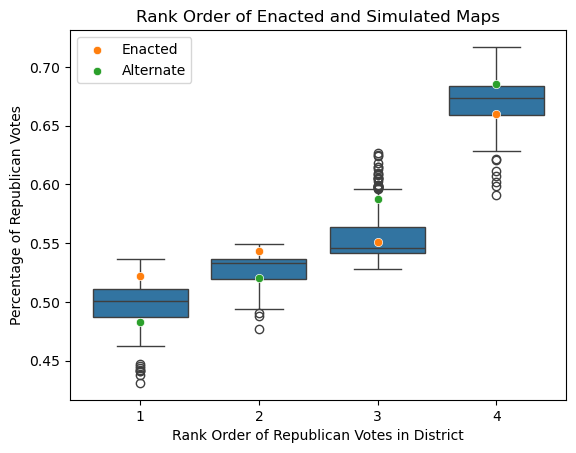

In [42]:
sns.boxplot(x=X, y=Y, zorder=1)
sns.scatterplot(x=x, y=y,zorder=2, label='Enacted')
sns.scatterplot(x=a, y=b, zorder=3, label='Alternate')
plt.xlabel('Rank Order of Republican Votes in District')
plt.ylabel('Percentage of Republican Votes')
plt.title('Rank Order of Enacted and Simulated Maps')
plt.legend(loc='upper left')

## Seat share and efficiency gap

In [21]:
files = glob.glob('./allocation_by_county/*.csv')
file_name = './allocation_by_county/seed_{}_by_county.csv'
winners_list=[]
for i in range(len(files)):
    # realloc_df=pd.read_csv(file)
    iter_number=str(i).rjust(3,'0')
    realloc_df=pd.read_csv(file_name.format(iter_number))
    votes_df['simulation_district']=realloc_df['DISTRICT']
    winners=winner_tabulation(votes_df, realloc_df)
    dems=winners.loc[winners['party_winner']=='D'].shape[0]
    reps=winners.loc[winners['party_winner']=='R'].shape[0]
    efficiency_gap=EG_func(votes_df, realloc_df)
    mean_med = mean_med_diff(votes_df, realloc_df)
    winners_list.append([iter_number, dems, reps, efficiency_gap, mean_med])

In [23]:
seat_share_df=pd.DataFrame(winners_list,columns=['iteration', 'dem_seats', 'rep_seats', 'efficiency_gap', 'mean_median_difference'])
seat_share_df

,iteration,dem_seats,rep_seats,efficiency_gap,mean_median_difference
0,000,0,4,37.92,1.33
1,001,0,4,37.92,3.74
2,002,1,3,-2.81,0.12
3,003,1,3,12.27,0.27
4,004,1,3,12.37,2.28
...,...,...,...,...,...
255,255,1,3,12.07,2.40
256,256,1,3,13.23,2.43
257,257,1,3,12.81,2.27
258,258,0,4,37.92,2.06


In [24]:
seat_share_df.to_csv('./data/seat_share_2022.csv', index=False, header=True)

Text(0.5, 1.0, 'Republican Seat Share in Simulated Maps')

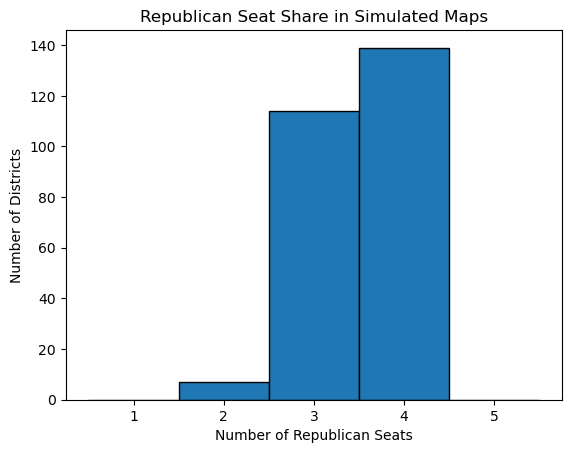

In [25]:
seats = seat_share_df['rep_seats']
plt.hist(seats,bins=np.arange(0,6)+0.5, ec="k")
plt.xlabel('Number of Republican Seats')
plt.ylabel('Number of Districts')
plt.title('Republican Seat Share in Simulated Maps')

In [26]:
#Percentage of simulated maps with at least 1 democratic winner based on 2022 voter numbers
len(seat_share_df.loc[seat_share_df['dem_seats']>0])/260

0.4653846153846154

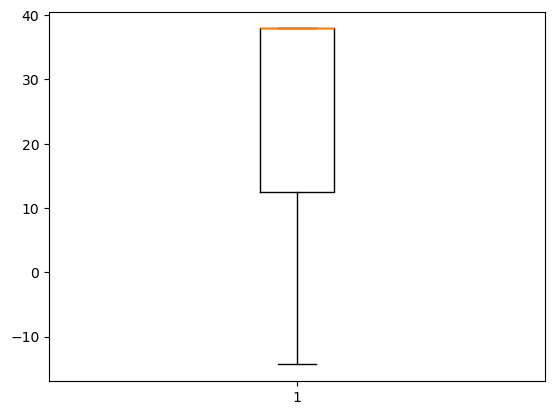

In [27]:
plt.boxplot(x=seat_share_df['efficiency_gap'])
plt.show()

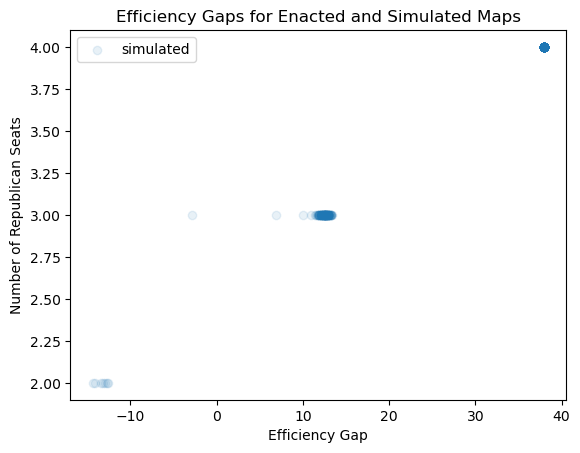

In [28]:
plt.scatter(seat_share_df['efficiency_gap'], seat_share_df['rep_seats'], alpha=.1, zorder=1, label='simulated')
# plt.scatter(x, y, zorder=2, label='enacted map')
# plt.scatter(a, b, zorder=3, label='alternate map')
plt.xlabel('Efficiency Gap')
plt.ylabel('Number of Republican Seats')
plt.title('Efficiency Gaps for Enacted and Simulated Maps')
plt.legend(loc='upper left')
plt.show()

<Axes: xlabel='efficiency_gap'>

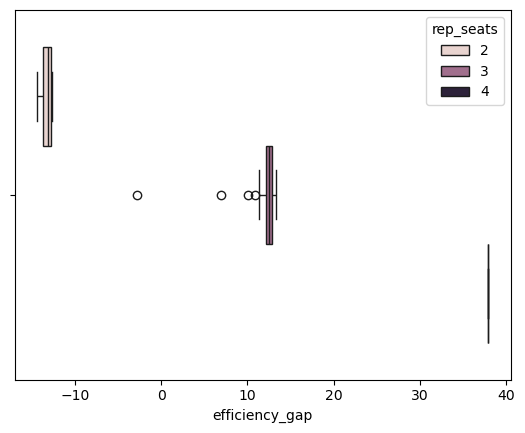

In [50]:
# boxplot separated by Republican seat share
# Need to label axes and add title
sns.boxplot(x=seat_share_df['efficiency_gap'], hue=seat_share_df['rep_seats'])